In [1]:
"""
Google Colab - Fast JSON-optimised Logistic Regression baseline
================================================================

Purpose
-------
Classify paired satellite images as:
    0 = safe
    1 = unsafe

This version is optimised for your Colab/Google Drive folder:

    /content/drive/MyDrive/DemoSet/
        DemoImage/
            hurricane-florence_00000117_pre_disaster.png
            hurricane-florence_00000117_post_disaster.png
            ...
        DemoLabel/
            hurricane-florence_00000117_pre_disaster.json
            hurricane-florence_00000117_post_disaster.json
            ...
        DemoTargetIfNecessary/
            *_target.png

Important changes from earlier version
--------------------------------------
1. Assumes data is already mounted at:
       /content/drive/MyDrive/DemoSet
2. Removes all CSV loading.
3. Uses post-disaster JSON labels only.
4. Extracts image features once, caches them, then trains quickly.
5. Uses a smaller grid search by default for faster Colab execution.
6. Treats UNSAFE as the positive class.

Default label rule
------------------
A tile is labelled unsafe if its post-disaster JSON contains at least one building with:
    minor-damage, major-damage, destroyed

To make the model less conservative, change:
    UNSAFE_DAMAGE_CLASSES = {"major-damage", "destroyed"}

Runtime guide
-------------
Typical Colab CPU runtime for this dataset:
    First run with feature extraction: ~1-4 minutes
    Later cached runs:                ~5-30 seconds
"""

'\nGoogle Colab - Fast JSON-optimised Logistic Regression baseline\n================================================================\n\nPurpose\n-------\nClassify paired satellite images as:\n    0 = safe\n    1 = unsafe\n\nThis version is optimised for your Colab/Google Drive folder:\n\n    /content/drive/MyDrive/DemoSet/\n        DemoImage/\n            hurricane-florence_00000117_pre_disaster.png\n            hurricane-florence_00000117_post_disaster.png\n            ...\n        DemoLabel/\n            hurricane-florence_00000117_pre_disaster.json\n            hurricane-florence_00000117_post_disaster.json\n            ...\n        DemoTargetIfNecessary/\n            *_target.png\n\nImportant changes from earlier version\n--------------------------------------\n1. Assumes data is already mounted at:\n       /content/drive/MyDrive/DemoSet\n2. Removes all CSV loading.\n3. Uses post-disaster JSON labels only.\n4. Extracts image features once, caches them, then trains quickly.\n5. Uses

In [ ]:
# ======================================================================================
# CELL 1 - Imports and configuration
# ======================================================================================

from __future__ import annotations

import json
import math
import re
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
# ======================================================================================
# CELL 2 - Fixed paths for your Google Drive dataset
# ======================================================================================

# If Drive is not mounted yet, run this once in Colab:
# from google.colab import drive
# drive.mount('/content/drive')

DATASET_DIR = Path("/content/drive/MyDrive/DemoSet")
IMAGE_DIR = DATASET_DIR / "DemoImage"
LABEL_DIR = DATASET_DIR / "DemoLabel"
TARGET_DIR = DATASET_DIR / "DemoTargetIfNecessary"  # Not used for this baseline.

OUTPUT_DIR = Path("/content/drive/MyDrive/DemoSet_LogReg_Outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_CACHE_PATH = OUTPUT_DIR / "cached_image_pair_features.csv"
MODEL_PATH = OUTPUT_DIR / "logistic_regression_model.joblib"
THRESHOLD_PATH = OUTPUT_DIR / "threshold.json"

SAFE_CLASS = 0
UNSAFE_CLASS = 1

# Conservative landing-zone setting:
# Any visible building damage makes the whole image tile unsafe.
UNSAFE_DAMAGE_CLASSES = {"minor-damage", "major-damage", "destroyed"}

# Less conservative alternative:
# UNSAFE_DAMAGE_CLASSES = {"major-damage", "destroyed"}

MIN_UNSAFE_BUILDINGS = 1
MIN_UNSAFE_RECALL = 0.80
MIN_SAFE_RECALL = 0.10  # Prevents the model from passing by predicting everything as unsafe.
MIN_THRESHOLD = 0.20

IMAGE_SIZE = 96           # 96 is faster than 128 and enough for this feature baseline.
GRID_SIZE = 3             # 3x3 grid is faster than 4x4.
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
RANDOM_STATE = 42
CV_FOLDS = 3              # Faster than 5. Increase to 5 once the workflow is proven.
FORCE_REBUILD_FEATURES = False

print("Dataset path:", DATASET_DIR)
print("Output path:", OUTPUT_DIR)

Dataset path: /content/drive/MyDrive/DemoSet
Output path: /content/drive/MyDrive/DemoSet_LogReg_Outputs


In [ ]:
# ======================================================================================
# CELL 3 - Quick folder inspection
# ======================================================================================

def list_files(folder: Path, limit: int = 8) -> None:
    print(f"\nFolder: {folder}")
    if not folder.exists():
        print("  Does not exist.")
        return
    files = sorted([p for p in folder.rglob("*") if p.is_file()])
    print(f"  Files found: {len(files)}")
    for p in files[:limit]:
        print("  -", p.relative_to(folder))
    if len(files) > limit:
        print(f"  ... {len(files) - limit} more")

list_files(DATASET_DIR)
list_files(IMAGE_DIR)
list_files(LABEL_DIR)
list_files(TARGET_DIR)

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Could not find image folder: {IMAGE_DIR}")
if not LABEL_DIR.exists():
    raise FileNotFoundError(f"Could not find label folder: {LABEL_DIR}")


Folder: /content/drive/MyDrive/DemoSet
  Files found: 417
  - .DS_Store
  - DemoImage/hurricane-florence_00000117_post_disaster.png
  - DemoImage/hurricane-florence_00000117_pre_disaster.png
  - DemoImage/hurricane-florence_00000119_post_disaster.png
  - DemoImage/hurricane-florence_00000119_pre_disaster.png
  - DemoImage/hurricane-florence_00000125_post_disaster.png
  - DemoImage/hurricane-florence_00000125_pre_disaster.png
  - DemoImage/hurricane-florence_00000127_post_disaster.png
  ... 409 more

Folder: /content/drive/MyDrive/DemoSet/DemoImage
  Files found: 140
  - hurricane-florence_00000117_post_disaster.png
  - hurricane-florence_00000117_pre_disaster.png
  - hurricane-florence_00000119_post_disaster.png
  - hurricane-florence_00000119_pre_disaster.png
  - hurricane-florence_00000125_post_disaster.png
  - hurricane-florence_00000125_pre_disaster.png
  - hurricane-florence_00000127_post_disaster.png
  - hurricane-florence_00000127_pre_disaster.png
  ... 132 more

Folder: /conte

In [ ]:
# ======================================================================================
# CELL 4 - JSON/image pairing and label extraction
# ======================================================================================

def image_files(folder: Path) -> List[Path]:
    allowed = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}
    return sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in allowed])


def json_files(folder: Path) -> List[Path]:
    return sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() == ".json"])


def is_pre_disaster(path: Path) -> bool:
    return "pre_disaster" in path.stem.lower()


def is_post_disaster(path: Path) -> bool:
    return "post_disaster" in path.stem.lower()


def base_event_id(path: Path) -> str:
    """
    Example:
        hurricane-florence_00000117_pre_disaster.png
        hurricane-florence_00000117_post_disaster.json
        hurricane-florence_00000117_post_disaster_target.png
    become:
        hurricane-florence_00000117
    """
    stem = path.stem.lower()
    stem = stem.replace("_target", "")
    stem = re.sub(r"_(pre|post)_disaster$", "", stem)
    return stem


def extract_subtypes_from_xbd_json(json_path: Path) -> List[str]:
    """Return building damage subtypes from an xBD-style JSON file."""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    features = data.get("features", {})
    xy_features = features.get("xy", [])

    subtypes = []
    for feature in xy_features:
        props = feature.get("properties", {}) or {}
        subtype = str(props.get("subtype", "")).strip().lower()
        if subtype:
            subtypes.append(subtype)

    return subtypes


def label_from_post_json(json_path: Path) -> Tuple[int, Dict[str, int]]:
    """
    Convert one post-disaster JSON file to a single safe/unsafe image-level label.
    """
    subtypes = extract_subtypes_from_xbd_json(json_path)

    counts = {
        "no-damage": 0,
        "minor-damage": 0,
        "major-damage": 0,
        "destroyed": 0,
        "un-classified": 0,
        "other": 0,
    }

    for subtype in subtypes:
        if subtype in counts:
            counts[subtype] += 1
        else:
            counts["other"] += 1

    unsafe_count = sum(counts.get(cls, 0) for cls in UNSAFE_DAMAGE_CLASSES)
    label = UNSAFE_CLASS if unsafe_count >= MIN_UNSAFE_BUILDINGS else SAFE_CLASS
    return label, counts


def build_metadata_from_json() -> pd.DataFrame:
    """
    Build a metadata table with one row per complete pre/post image pair.
    """
    all_images = image_files(IMAGE_DIR)
    all_jsons = json_files(LABEL_DIR)

    pre_images = [p for p in all_images if is_pre_disaster(p)]
    post_images = [p for p in all_images if is_post_disaster(p)]
    post_jsons = [p for p in all_jsons if is_post_disaster(p)]

    pre_by_id = {base_event_id(p): p for p in pre_images}
    post_by_id = {base_event_id(p): p for p in post_images}
    json_by_id = {base_event_id(p): p for p in post_jsons}

    common_ids = sorted(set(pre_by_id) & set(post_by_id) & set(json_by_id))

    print("\nPairing source files:")
    print(f"  Pre images found:       {len(pre_images)}")
    print(f"  Post images found:      {len(post_images)}")
    print(f"  Post JSON labels found: {len(post_jsons)}")
    print(f"  Complete paired samples:{len(common_ids)}")

    rows = []
    for sample_id in common_ids:
        label, counts = label_from_post_json(json_by_id[sample_id])
        rows.append(
            {
                "sample_id": sample_id,
                "pre_image_path": str(pre_by_id[sample_id]),
                "post_image_path": str(post_by_id[sample_id]),
                "post_json_path": str(json_by_id[sample_id]),
                "label": label,
                "label_text": "unsafe" if label == UNSAFE_CLASS else "safe",
                **{f"json_count_{k}": v for k, v in counts.items()},
            }
        )

    if not rows:
        raise ValueError("No complete pre/post/json pairs found.")

    metadata = pd.DataFrame(rows)

    print("\nLabel distribution:")
    print(metadata["label_text"].value_counts())

    if metadata["label"].nunique() != 2:
        raise ValueError(
            "Only one class was found. Logistic regression needs both safe and unsafe samples.\n"
            "Try changing UNSAFE_DAMAGE_CLASSES. For example:\n"
            "  UNSAFE_DAMAGE_CLASSES = {'major-damage', 'destroyed'}\n"
            "or\n"
            "  UNSAFE_DAMAGE_CLASSES = {'minor-damage', 'major-damage', 'destroyed'}"
        )

    metadata.to_csv(OUTPUT_DIR / "metadata_from_json.csv", index=False)
    return metadata

metadata = build_metadata_from_json()
display(metadata.head())


Pairing source files:
  Pre images found:       70
  Post images found:      70
  Post JSON labels found: 69
  Complete paired samples:62

Label distribution:
label_text
unsafe    35
safe      27
Name: count, dtype: int64


,sample_id,pre_image_path,post_image_path,post_json_path,label,label_text,json_count_no-damage,json_count_minor-damage,json_count_major-damage,json_count_destroyed,json_count_un-classified,json_count_other
0,hurricane-florence_00000117,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoLabel/hurri...,0,safe,10,0,0,0,2,0
1,hurricane-florence_00000119,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoLabel/hurri...,1,unsafe,0,0,10,0,0,0
2,hurricane-florence_00000125,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoLabel/hurri...,1,unsafe,0,0,4,0,0,0
3,hurricane-florence_00000127,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoLabel/hurri...,1,unsafe,0,0,4,0,0,0
4,hurricane-florence_00000128,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoImage/hurri...,/content/drive/MyDrive/DemoSet/DemoLabel/hurri...,1,unsafe,0,0,1,0,0,0


In [ ]:
# ======================================================================================
# CELL 5 - Fast image feature extraction
# ======================================================================================

def load_rgb(path: Path, image_size: int = IMAGE_SIZE) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB")
        img = img.resize((image_size, image_size), resample=Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0


def safe_divide(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return a / (b + eps)


def stats(values: np.ndarray, prefix: str) -> Dict[str, float]:
    values = np.asarray(values, dtype=np.float32).reshape(-1)
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_p10": float(np.percentile(values, 10)),
        f"{prefix}_p50": float(np.percentile(values, 50)),
        f"{prefix}_p90": float(np.percentile(values, 90)),
    }


def image_features(img: np.ndarray, prefix: str) -> Dict[str, float]:
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    brightness = (r + g + b) / 3.0
    exg = 2 * g - r - b
    vari = safe_divide(g - r, g + r - b)

    features = {}
    for name, arr in [
        ("r", r),
        ("g", g),
        ("b", b),
        ("gray", gray),
        ("brightness", brightness),
        ("exg", exg),
        ("vari", vari),
    ]:
        features.update(stats(arr, f"{prefix}_{name}"))

    # Simple texture proxy.
    gy, gx = np.gradient(gray)
    grad = np.sqrt(gx**2 + gy**2)
    features.update(stats(grad, f"{prefix}_gradient"))

    return features


def grid_mean_features(img: np.ndarray, prefix: str, grid_size: int = GRID_SIZE) -> Dict[str, float]:
    h, w, _ = img.shape
    cell_h = h // grid_size
    cell_w = w // grid_size
    features = {}

    for row in range(grid_size):
        for col in range(grid_size):
            patch = img[row * cell_h : (row + 1) * cell_h, col * cell_w : (col + 1) * cell_w, :]
            r, g, b = patch[..., 0], patch[..., 1], patch[..., 2]
            gray = 0.299 * r + 0.587 * g + 0.114 * b
            exg = 2 * g - r - b
            base = f"{prefix}_cell_{row}_{col}"
            features[f"{base}_gray_mean"] = float(np.mean(gray))
            features[f"{base}_gray_std"] = float(np.std(gray))
            features[f"{base}_exg_mean"] = float(np.mean(exg))
            features[f"{base}_r_mean"] = float(np.mean(r))
            features[f"{base}_g_mean"] = float(np.mean(g))
            features[f"{base}_b_mean"] = float(np.mean(b))

    return features


def pair_features(pre_path: Path, post_path: Path) -> Dict[str, float]:
    pre = load_rgb(pre_path)
    post = load_rgb(post_path)

    diff = post - pre
    abs_diff = np.abs(diff)
    change_mag = np.sqrt(np.sum(diff**2, axis=-1)) / math.sqrt(3.0)

    pre_gray = 0.299 * pre[..., 0] + 0.587 * pre[..., 1] + 0.114 * pre[..., 2]
    post_gray = 0.299 * post[..., 0] + 0.587 * post[..., 1] + 0.114 * post[..., 2]

    features = {}
    features.update(image_features(pre, "pre"))
    features.update(image_features(post, "post"))
    features.update(image_features(abs_diff, "abs_change"))
    features.update(grid_mean_features(pre, "pre"))
    features.update(grid_mean_features(post, "post"))
    features.update(grid_mean_features(abs_diff, "abs_change"))

    features.update(stats(change_mag, "change_magnitude"))
    features.update(stats(post_gray - pre_gray, "delta_gray"))

    for i, ch in enumerate(["r", "g", "b"]):
        features.update(stats(diff[..., i], f"delta_{ch}"))

    # Compact histogram of change magnitude.
    hist, _ = np.histogram(change_mag.reshape(-1), bins=8, range=(0, 1), density=True)
    for i, v in enumerate(hist):
        features[f"change_hist_{i}"] = float(v)

    return features


def build_or_load_feature_table(metadata: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE_PATH.exists() and not FORCE_REBUILD_FEATURES:
        print("\nLoading cached features:", FEATURE_CACHE_PATH)
        feature_table = pd.read_csv(FEATURE_CACHE_PATH)
        return feature_table

    print("\nExtracting image features once. This is the slow part, but it is cached afterwards.")
    rows = []
    for i, row in metadata.iterrows():
        if i % 10 == 0:
            print(f"  Processing {i + 1}/{len(metadata)}")

        features = pair_features(Path(row["pre_image_path"]), Path(row["post_image_path"]))
        rows.append(
            {
                "sample_id": row["sample_id"],
                "label": int(row["label"]),
                "label_text": row["label_text"],
                **features,
            }
        )

    feature_table = pd.DataFrame(rows).fillna(0.0)
    feature_table.to_csv(FEATURE_CACHE_PATH, index=False)
    print("Saved feature cache:", FEATURE_CACHE_PATH)
    return feature_table

feature_table = build_or_load_feature_table(metadata)
print("\nFeature table shape:", feature_table.shape)
display(feature_table.head())


Loading cached features: /content/drive/MyDrive/DemoSet_LogReg_Outputs/cached_image_pair_features.csv

Feature table shape: (62, 318)


,sample_id,label,label_text,pre_r_mean,pre_r_std,pre_r_p10,pre_r_p50,pre_r_p90,pre_g_mean,pre_g_std,...,delta_b_p50,delta_b_p90,change_hist_0,change_hist_1,change_hist_2,change_hist_3,change_hist_4,change_hist_5,change_hist_6,change_hist_7
0,hurricane-florence_00000117,0,safe,0.390257,0.094235,0.254902,0.403922,0.501961,0.376295,0.043153,...,0.003922,0.066667,6.825521,1.171875,0.002604,0.000000,0.000000,0.000000,0.0,0.0
1,hurricane-florence_00000119,1,unsafe,0.225167,0.093636,0.125490,0.207843,0.345098,0.276066,0.079472,...,0.015686,0.090196,6.769965,1.161458,0.054688,0.010417,0.003472,0.000000,0.0,0.0
2,hurricane-florence_00000125,1,unsafe,0.368946,0.131329,0.164706,0.392157,0.525490,0.408099,0.106319,...,-0.176471,-0.043137,1.793403,2.929688,2.908854,0.343750,0.024306,0.000000,0.0,0.0
3,hurricane-florence_00000127,1,unsafe,0.228181,0.134725,0.121569,0.176471,0.431373,0.298266,0.113050,...,0.000000,0.039216,6.308160,1.136285,0.301215,0.182292,0.062500,0.009549,0.0,0.0
4,hurricane-florence_00000128,1,unsafe,0.202371,0.097050,0.117647,0.184314,0.298039,0.264353,0.069068,...,-0.019608,0.015686,7.493924,0.427951,0.078125,0.000000,0.000000,0.000000,0.0,0.0


In [ ]:
# ======================================================================================
# CELL 6 - Train/validation/test split
# ======================================================================================

non_feature_cols = {"sample_id", "label", "label_text"}
feature_cols = [c for c in feature_table.columns if c not in non_feature_cols]

X_all = feature_table[feature_cols].to_numpy(dtype=np.float64)
y_all = feature_table["label"].to_numpy(dtype=int)
sample_ids = feature_table["sample_id"].to_numpy()

safe_count = int(np.sum(y_all == SAFE_CLASS))
unsafe_count = int(np.sum(y_all == UNSAFE_CLASS))
min_class_count = min(safe_count, unsafe_count)

print("\nClass counts:")
print("  Safe:  ", safe_count)
print("  Unsafe:", unsafe_count)

if min_class_count < 3:
    raise ValueError("Not enough examples in the smaller class for a reliable train/test split.")

X_train_val, X_test, y_train_val, y_test, ids_train_val, ids_test = train_test_split(
    X_all,
    y_all,
    sample_ids,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_train_val,
    y_train_val,
    ids_train_val,
    test_size=VALIDATION_SIZE,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

print("\nSplit sizes:")
print("  Train:     ", len(y_train))
print("  Validation:", len(y_val))
print("  Test:      ", len(y_test))


Class counts:
  Safe:   27
  Unsafe: 35

Split sizes:
  Train:      39
  Validation: 10
  Test:       13


In [ ]:
# ======================================================================================
# CELL 7 - Fast logistic regression training
# ======================================================================================

pipeline = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Fast default grid. Expand later if needed.
param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__penalty": ["l2"],
}

# Fuller but slower alternative:
# param_grid = {
#     "model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
#     "model__penalty": ["l1", "l2"],
# }

cv_folds = min(CV_FOLDS, int(min(np.sum(y_train == SAFE_CLASS), np.sum(y_train == UNSAFE_CLASS))))
if cv_folds < 2:
    raise ValueError("Not enough samples per class in training data for cross-validation.")

scoring = {
    "f1_unsafe": "f1",
    "recall_unsafe": "recall",
    "precision_unsafe": "precision",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
}

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_unsafe",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print("\nTraining Logistic Regression...")
search.fit(X_train, y_train)

print("\nBest parameters:")
print(search.best_params_)
print(f"Best CV f1_unsafe: {search.best_score_:.4f}")

best_model = search.best_estimator_


Training Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2'}
Best CV f1_unsafe: 0.2540


In [ ]:
# ======================================================================================
# CELL 8 - Threshold tuning for safety-critical classification
# ======================================================================================

def choose_threshold_for_safety(
    y_true: np.ndarray,
    unsafe_prob: np.ndarray,
    min_unsafe_recall: float = MIN_UNSAFE_RECALL,
    min_safe_recall: float = MIN_SAFE_RECALL,
) -> Tuple[float, pd.DataFrame]:
    """
    Select a threshold that favours unsafe recall but prevents the model from
    passing simply by predicting every tile as unsafe.

    Requirements:
        - unsafe recall should be at least min_unsafe_recall
        - safe recall should be at least min_safe_recall

    If no threshold satisfies both, it falls back to the threshold with the best
    balanced accuracy.
    """
    thresholds = np.linspace(MIN_THRESHOLD, 0.99, 80)
    records = []

    for threshold in thresholds:
        y_pred = (unsafe_prob >= threshold).astype(int)
        records.append(
            {
                "threshold": float(threshold),
                "precision_unsafe": precision_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0),
                "recall_unsafe": recall_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0),
                "f1_unsafe": f1_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0),
                "recall_safe": recall_score(y_true, y_pred, pos_label=SAFE_CLASS, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            }
        )

    curve = pd.DataFrame(records)

    eligible = curve[
        (curve["recall_unsafe"] >= min_unsafe_recall) &
        (curve["recall_safe"] >= min_safe_recall)
    ]

    if len(eligible) > 0:
        best = eligible.sort_values(
            ["balanced_accuracy", "f1_unsafe", "precision_unsafe"],
            ascending=False,
        ).iloc[0]
    else:
        print("Warning: no threshold satisfied both unsafe recall and safe recall.")
        print("Falling back to best balanced accuracy threshold.")
        best = curve.sort_values(
            ["balanced_accuracy", "recall_unsafe", "f1_unsafe"],
            ascending=False,
        ).iloc[0]

    return float(best["threshold"]), curve

val_prob = best_model.predict_proba(X_val)[:, list(best_model.classes_).index(UNSAFE_CLASS)]
threshold, threshold_curve = choose_threshold_for_safety(y_val, val_prob)
threshold_curve.to_csv(OUTPUT_DIR / "threshold_tuning_curve.csv", index=False)

print("\nSelected unsafe threshold:", round(threshold, 3))
print("Target minimum unsafe recall:", MIN_UNSAFE_RECALL)
print("Target minimum safe recall:", MIN_SAFE_RECALL)


Selected unsafe threshold: 0.2
Target minimum unsafe recall: 0.8
Target minimum safe recall: 0.1


In [ ]:
# ======================================================================================
# CELL 9 - Final fit and metrics
# ======================================================================================

def compute_metrics(y_true: np.ndarray, unsafe_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (unsafe_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[SAFE_CLASS, UNSAFE_CLASS]).ravel()

    results = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_unsafe": float(precision_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0)),
        "recall_unsafe": float(recall_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0)),
        "f1_unsafe": float(f1_score(y_true, y_pred, pos_label=UNSAFE_CLASS, zero_division=0)),
        "precision_safe": float(precision_score(y_true, y_pred, pos_label=SAFE_CLASS, zero_division=0)),
        "recall_safe": float(recall_score(y_true, y_pred, pos_label=SAFE_CLASS, zero_division=0)),
        "f1_safe": float(f1_score(y_true, y_pred, pos_label=SAFE_CLASS, zero_division=0)),
        "tn_safe_correct": int(tn),
        "fp_safe_predicted_unsafe": int(fp),
        "fn_unsafe_predicted_safe": int(fn),
        "tp_unsafe_correct": int(tp),
        "unsafe_miss_rate": float(fn / (fn + tp)) if (fn + tp) else 0.0,
        "false_safe_rate_among_predicted_safe": float(fn / (fn + tn)) if (fn + tn) else 0.0,
    }

    if len(np.unique(y_true)) == 2:
        results["roc_auc"] = float(roc_auc_score(y_true, unsafe_prob))
        results["average_precision"] = float(average_precision_score(y_true, unsafe_prob))

    return results


def print_report(y_true: np.ndarray, unsafe_prob: np.ndarray, threshold: float, title: str) -> None:
    y_pred = (unsafe_prob >= threshold).astype(int)
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    print(f"Threshold: {threshold:.3f}")
    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[SAFE_CLASS, UNSAFE_CLASS],
            target_names=["safe", "unsafe"],
            zero_division=0,
        )
    )
    print("Confusion matrix: rows=actual, columns=predicted")
    print("[[safe->safe, safe->unsafe],")
    print(" [unsafe->safe, unsafe->unsafe]]")
    print(confusion_matrix(y_true, y_pred, labels=[SAFE_CLASS, UNSAFE_CLASS]))

    metrics = compute_metrics(y_true, unsafe_prob, threshold)
    print("\nKey safety metrics:")
    for key in [
        "recall_unsafe",
        "precision_unsafe",
        "f1_unsafe",
        "unsafe_miss_rate",
        "false_safe_rate_among_predicted_safe",
        "balanced_accuracy",
        "roc_auc",
        "average_precision",
    ]:
        if key in metrics:
            print(f"  {key}: {metrics[key]:.4f}")

print_report(y_val, val_prob, threshold, "VALIDATION METRICS")

# Refit final selected model on train + validation, then test once.
final_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
final_model.set_params(**search.best_params_)
final_model.fit(X_train_val, y_train_val)

test_prob = final_model.predict_proba(X_test)[:, list(final_model.classes_).index(UNSAFE_CLASS)]
y_test_pred = (test_prob >= threshold).astype(int)

print_report(y_test, test_prob, threshold, "HELD-OUT TEST METRICS")


VALIDATION METRICS
Threshold: 0.200

Classification report:
              precision    recall  f1-score   support

        safe       0.50      0.25      0.33         4
      unsafe       0.62      0.83      0.71         6

    accuracy                           0.60        10
   macro avg       0.56      0.54      0.52        10
weighted avg       0.57      0.60      0.56        10

Confusion matrix: rows=actual, columns=predicted
[[safe->safe, safe->unsafe],
 [unsafe->safe, unsafe->unsafe]]
[[1 3]
 [1 5]]

Key safety metrics:
  recall_unsafe: 0.8333
  precision_unsafe: 0.6250
  f1_unsafe: 0.7143
  unsafe_miss_rate: 0.1667
  false_safe_rate_among_predicted_safe: 0.5000
  balanced_accuracy: 0.5417
  roc_auc: 0.5000
  average_precision: 0.6347

HELD-OUT TEST METRICS
Threshold: 0.200

Classification report:
              precision    recall  f1-score   support

        safe       0.50      0.17      0.25         6
      unsafe       0.55      0.86      0.67         7

    accuracy      

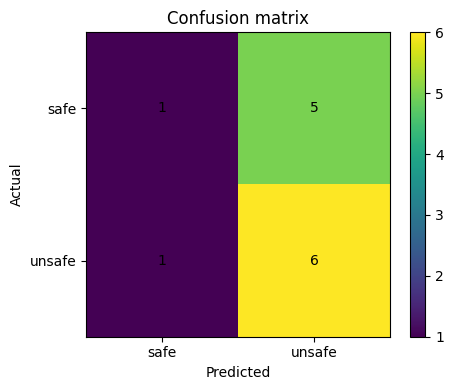

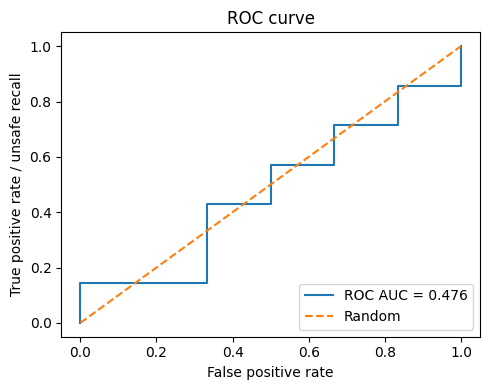

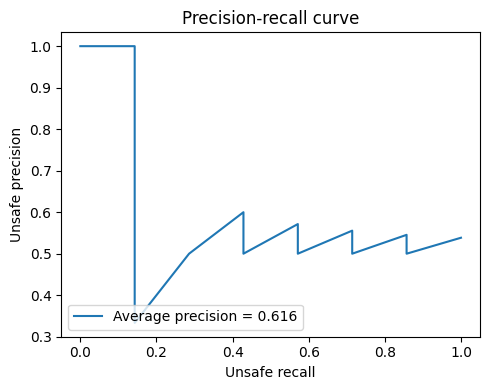


Saved outputs:
- cached_image_pair_features.csv
- confusion_matrix.png
- feature_importance.csv
- grid_search_results.csv
- logistic_regression_model.joblib
- metadata_from_json.csv
- metrics.json
- precision_recall_curve.png
- roc_curve.png
- test_predictions.csv
- threshold.json
- threshold_tuning_curve.csv

Top 20 features by absolute coefficient:


,feature,coefficient,abs_coefficient
175,post_cell_0_0_gray_std,-0.176982,0.176982
66,post_exg_std,0.163688,0.163688
106,abs_change_exg_std,0.162049,0.162049
229,abs_change_cell_0_0_gray_std,0.141002,0.141002
70,post_vari_mean,0.139499,0.139499
71,post_vari_std,0.139437,0.139437
217,post_cell_2_1_gray_std,-0.137143,0.137143
139,pre_cell_1_0_gray_std,-0.132139,0.132139
230,abs_change_cell_0_0_exg_mean,0.123927,0.123927
32,pre_vari_p10,0.123190,0.123190



Test predictions:


,sample_id,actual_label,actual_text,unsafe_probability,predicted_label,predicted_text
0,palu-tsunami_00000037,0,safe,0.564876,1,unsafe
1,santa-rosa-wildfire_00000019,1,unsafe,0.653902,1,unsafe
2,hurricane-michael_00000018,1,unsafe,0.449295,1,unsafe
3,mexico-earthquake_00000135,0,safe,0.727988,1,unsafe
4,mexico-earthquake_00000117,1,unsafe,0.287592,1,unsafe
5,palu-tsunami_00000094,0,safe,0.324527,1,unsafe
6,palu-tsunami_00000113,1,unsafe,0.332971,1,unsafe
7,mexico-earthquake_00000139,0,safe,0.670306,1,unsafe
8,santa-rosa-wildfire_00000038,1,unsafe,0.623502,1,unsafe
9,santa-rosa-wildfire_00000266,1,unsafe,0.818057,1,unsafe


In [ ]:
   # ======================================================================================
# CELL 10 - Save outputs, plots and feature importance
# ======================================================================================

def save_confusion_matrix_plot(y_true: np.ndarray, y_pred: np.ndarray, output_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=[SAFE_CLASS, UNSAFE_CLASS])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title("Confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], labels=["safe", "unsafe"])
    ax.set_yticks([0, 1], labels=["safe", "unsafe"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()


def save_roc_curve_plot(y_true: np.ndarray, unsafe_prob: np.ndarray, output_path: Path) -> None:
    fpr, tpr, _ = roc_curve(y_true, unsafe_prob)
    auc = roc_auc_score(y_true, unsafe_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate / unsafe recall")
    ax.set_title("ROC curve")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()


def save_precision_recall_plot(y_true: np.ndarray, unsafe_prob: np.ndarray, output_path: Path) -> None:
    precision, recall, _ = precision_recall_curve(y_true, unsafe_prob, pos_label=UNSAFE_CLASS)
    ap = average_precision_score(y_true, unsafe_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"Average precision = {ap:.3f}")
    ax.set_xlabel("Unsafe recall")
    ax.set_ylabel("Unsafe precision")
    ax.set_title("Precision-recall curve")
    ax.legend(loc="lower left")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()

validation_metrics = compute_metrics(y_val, val_prob, threshold)
test_metrics = compute_metrics(y_test, test_prob, threshold)

results = {
    "dataset_dir": str(DATASET_DIR),
    "unsafe_damage_classes": sorted(list(UNSAFE_DAMAGE_CLASSES)),
    "min_unsafe_buildings": MIN_UNSAFE_BUILDINGS,
    "image_size": IMAGE_SIZE,
    "grid_size": GRID_SIZE,
    "best_params": search.best_params_,
    "selected_threshold": threshold,
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "class_mapping": {"safe": SAFE_CLASS, "unsafe": UNSAFE_CLASS},
}

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump({"unsafe_probability_threshold": threshold}, f, indent=2)

joblib.dump(
    {
        "model": final_model,
        "feature_cols": feature_cols,
        "threshold": threshold,
        "unsafe_damage_classes": sorted(list(UNSAFE_DAMAGE_CLASSES)),
        "image_size": IMAGE_SIZE,
        "grid_size": GRID_SIZE,
    },
    MODEL_PATH,
)

pd.DataFrame(search.cv_results_).to_csv(OUTPUT_DIR / "grid_search_results.csv", index=False)

predictions = pd.DataFrame(
    {
        "sample_id": ids_test,
        "actual_label": y_test,
        "actual_text": np.where(y_test == UNSAFE_CLASS, "unsafe", "safe"),
        "unsafe_probability": test_prob,
        "predicted_label": y_test_pred,
        "predicted_text": np.where(y_test_pred == UNSAFE_CLASS, "unsafe", "safe"),
    }
)
predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

coefs = final_model.named_steps["model"].coef_[0]
feature_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
    }
).sort_values("abs_coefficient", ascending=False)
feature_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

save_confusion_matrix_plot(y_test, y_test_pred, OUTPUT_DIR / "confusion_matrix.png")
save_roc_curve_plot(y_test, test_prob, OUTPUT_DIR / "roc_curve.png")
save_precision_recall_plot(y_test, test_prob, OUTPUT_DIR / "precision_recall_curve.png")

print("\nSaved outputs:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)

print("\nTop 20 features by absolute coefficient:")
display(feature_importance.head(20))

print("\nTest predictions:")
display(predictions.head(20))

In [ ]:
# ======================================================================================
# CELL 11 - Predict one new pre/post image pair
# ======================================================================================

def predict_image_pair(pre_image_path: str, post_image_path: str) -> Dict[str, object]:
    bundle = joblib.load(MODEL_PATH)
    loaded_model = bundle["model"]
    loaded_feature_cols = bundle["feature_cols"]
    loaded_threshold = bundle["threshold"]

    features = pair_features(Path(pre_image_path), Path(post_image_path))
    X_new = pd.DataFrame([features]).reindex(columns=loaded_feature_cols, fill_value=0.0)

    unsafe_prob = loaded_model.predict_proba(X_new.to_numpy(dtype=np.float64))[:, list(loaded_model.classes_).index(UNSAFE_CLASS)][0]
    predicted = UNSAFE_CLASS if unsafe_prob >= loaded_threshold else SAFE_CLASS

    return {
        "unsafe_probability": float(unsafe_prob),
        "threshold": float(loaded_threshold),
        "predicted_label": int(predicted),
        "predicted_text": "unsafe" if predicted == UNSAFE_CLASS else "safe",
    }

# Example:
# result = predict_image_pair(
#     "/content/drive/MyDrive/DemoSet/DemoImage/hurricane-florence_00000117_pre_disaster.png",
#     "/content/drive/MyDrive/DemoSet/DemoImage/hurricane-florence_00000117_post_disaster.png",
# )
# print(result)


KNN model